In [1]:
# Cell 1: Imports and style configuration

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality figures
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

print("✓ Imports loaded successfully")

✓ Imports loaded successfully


In [2]:
# Cell 2: CONFIG — PASTE PATHS HERE

# ============================================================
# REQUIRED INPUT FILES (all 3 databases):
# - a2_metrics_Supabase.csv
# - a2_metrics_MongoDB.csv
# - a2_metrics_AstraDB.csv
# ============================================================

# ============================================================
# EDIT THESE FOUR LINES
# ============================================================

# Full path to Supabase a2_metrics.csv
supa_csv = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Supa_results\A2\Data\a2_metrics_Supabase.csv"

# Full path to MongoDB a2_metrics.csv
mongo_csv = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Mongo_results\A2\Data\a2_metrics_MongoDB.csv"

# Full path to AstraDB a2_metrics.csv
astra_csv = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Astra_results\A2\Data\a2_metrics_AstraDB.csv"

# Full path to OUTPUT FOLDER (where figures will be saved)
output_dir = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A2"

# ============================================================
# DO NOT EDIT BELOW
# ============================================================

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Output filenames
fig2_filename = os.path.join(output_dir, "fig2_a2_iqr_comparison_combined.png")
fig2_outlier_filename = os.path.join(output_dir, "fig2_outliers_a2_iqr_comparison.png")

print("Input files:")
print("  Supabase:", supa_csv)
print("  MongoDB:", mongo_csv)
print("  AstraDB:", astra_csv)
print("\nOutput folder:", output_dir)
print("\nFigures will be saved as:")
print("  Figure 2:", fig2_filename)
print("  Figure 2 Outliers (if needed):", fig2_outlier_filename)

# Verify all inputs exist
missing = []
if not os.path.exists(supa_csv):
    missing.append("Supabase")
if not os.path.exists(mongo_csv):
    missing.append("MongoDB")
if not os.path.exists(astra_csv):
    missing.append("AstraDB")

if missing:
    print(f"\n⚠️ MISSING FILES for: {', '.join(missing)}")
    print("Please check your paths!")
else:
    print("\n✓ All input files found!")

Input files:
  Supabase: C:\Users\avyaa\Desktop\Research Stuff\Results\Supa_results\A2\Data\a2_metrics_Supabase.csv
  MongoDB: C:\Users\avyaa\Desktop\Research Stuff\Results\Mongo_results\A2\Data\a2_metrics_MongoDB.csv
  AstraDB: C:\Users\avyaa\Desktop\Research Stuff\Results\Astra_results\A2\Data\a2_metrics_AstraDB.csv

Output folder: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A2

Figures will be saved as:
  Figure 2: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A2\fig2_a2_iqr_comparison_combined.png
  Figure 2 Outliers (if needed): C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A2\fig2_outliers_a2_iqr_comparison.png

✓ All input files found!


In [3]:
# Cell 3: Load all three databases' metrics and validate

# Load CSVs
df_supa = pd.read_csv(supa_csv)
df_mongo = pd.read_csv(mongo_csv)
df_astra = pd.read_csv(astra_csv)

# Required columns
required = ["query_id", "a2_p50_ms", "iqr_ms"]

# Validate columns
for name, df in [("Supabase", df_supa), ("MongoDB", df_mongo), ("AstraDB", df_astra)]:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

# Sort all by query_id for consistent ordering
df_supa = df_supa.sort_values("query_id").reset_index(drop=True)
df_mongo = df_mongo.sort_values("query_id").reset_index(drop=True)
df_astra = df_astra.sort_values("query_id").reset_index(drop=True)

# Verify all have same queries
queries = df_supa["query_id"].values
if not (np.array_equal(queries, df_mongo["query_id"].values) and 
        np.array_equal(queries, df_astra["query_id"].values)):
    print("⚠️ WARNING: Databases have different query sets!")
    print("Using intersection of queries...")
    # Get common queries
    common = set(df_supa["query_id"]) & set(df_mongo["query_id"]) & set(df_astra["query_id"])
    queries = sorted(common)
    df_supa = df_supa[df_supa["query_id"].isin(queries)].sort_values("query_id").reset_index(drop=True)
    df_mongo = df_mongo[df_mongo["query_id"].isin(queries)].sort_values("query_id").reset_index(drop=True)
    df_astra = df_astra[df_astra["query_id"].isin(queries)].sort_values("query_id").reset_index(drop=True)

print("✓ Data loaded and validated")
print(f"  Queries: {len(queries)} ({list(queries)})")
print(f"  Supabase rows: {len(df_supa)}")
print(f"  MongoDB rows: {len(df_mongo)}")
print(f"  AstraDB rows: {len(df_astra)}")

✓ Data loaded and validated
  Queries: 10 (['R1', 'R10', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9'])
  Supabase rows: 10
  MongoDB rows: 10
  AstraDB rows: 10


In [4]:
# Cell 4: Outlier Detection (Query-Level based on IQR)

print("\n" + "=" * 60)
print("OUTLIER DETECTION")
print("=" * 60)

# Combine all IQR values to compute overall statistics
all_iqr = np.concatenate([
    df_supa["iqr_ms"].values,
    df_mongo["iqr_ms"].values,
    df_astra["iqr_ms"].values
])

# Overall statistics
overall_median_iqr = np.nanmedian(all_iqr)
overall_max_iqr = np.nanmax(all_iqr)

print(f"Overall median IQR: {overall_median_iqr:.2f} ms")
print(f"Overall max IQR: {overall_max_iqr:.2f} ms")

# Detect outlier queries (any database with IQR > thresholds for that query)
# Use IQR > 10× median OR absolute IQR > 500ms as thresholds
outlier_queries = []
normal_queries = []

for i, q in enumerate(queries):
    # Get IQR values for this query across all databases
    q_iqr_vals = [
        df_supa.iloc[i]["iqr_ms"],
        df_mongo.iloc[i]["iqr_ms"],
        df_astra.iloc[i]["iqr_ms"]
    ]
    max_q_iqr = np.nanmax(q_iqr_vals)
    
    # Flag if ANY database shows extreme IQR for this query
    if max_q_iqr > 10 * overall_median_iqr or max_q_iqr > 500:
        outlier_queries.append(q)
        print(f"\n🚨 OUTLIER QUERY: {q}")
        print(f"   Max IQR across DBs: {max_q_iqr:.2f} ms ({max_q_iqr/overall_median_iqr:.1f}× median IQR)")
    else:
        normal_queries.append(q)

if len(outlier_queries) > 0:
    print(f"\n✓ Detected {len(outlier_queries)} outlier query(s): {outlier_queries}")
    print(f"✓ Main figure will show {len(normal_queries)} normal queries")
    print(f"✓ Outlier figure will be generated separately")
else:
    print(f"\n✓ No extreme outliers detected")
    print(f"✓ All {len(queries)} queries in main figure")
    normal_queries = list(queries)

# Filter masks
mask_normal = [q in normal_queries for q in queries]
mask_outlier = [q in outlier_queries for q in queries]


OUTLIER DETECTION
Overall median IQR: 1.35 ms
Overall max IQR: 1246.54 ms

🚨 OUTLIER QUERY: R10
   Max IQR across DBs: 866.32 ms (641.3× median IQR)

🚨 OUTLIER QUERY: R6
   Max IQR across DBs: 1246.54 ms (922.8× median IQR)

✓ Detected 2 outlier query(s): ['R10', 'R6']
✓ Main figure will show 8 normal queries
✓ Outlier figure will be generated separately



MAIN FIGURE GENERATION
✓ Figure 2 saved: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A2\fig2_a2_iqr_comparison_combined.png


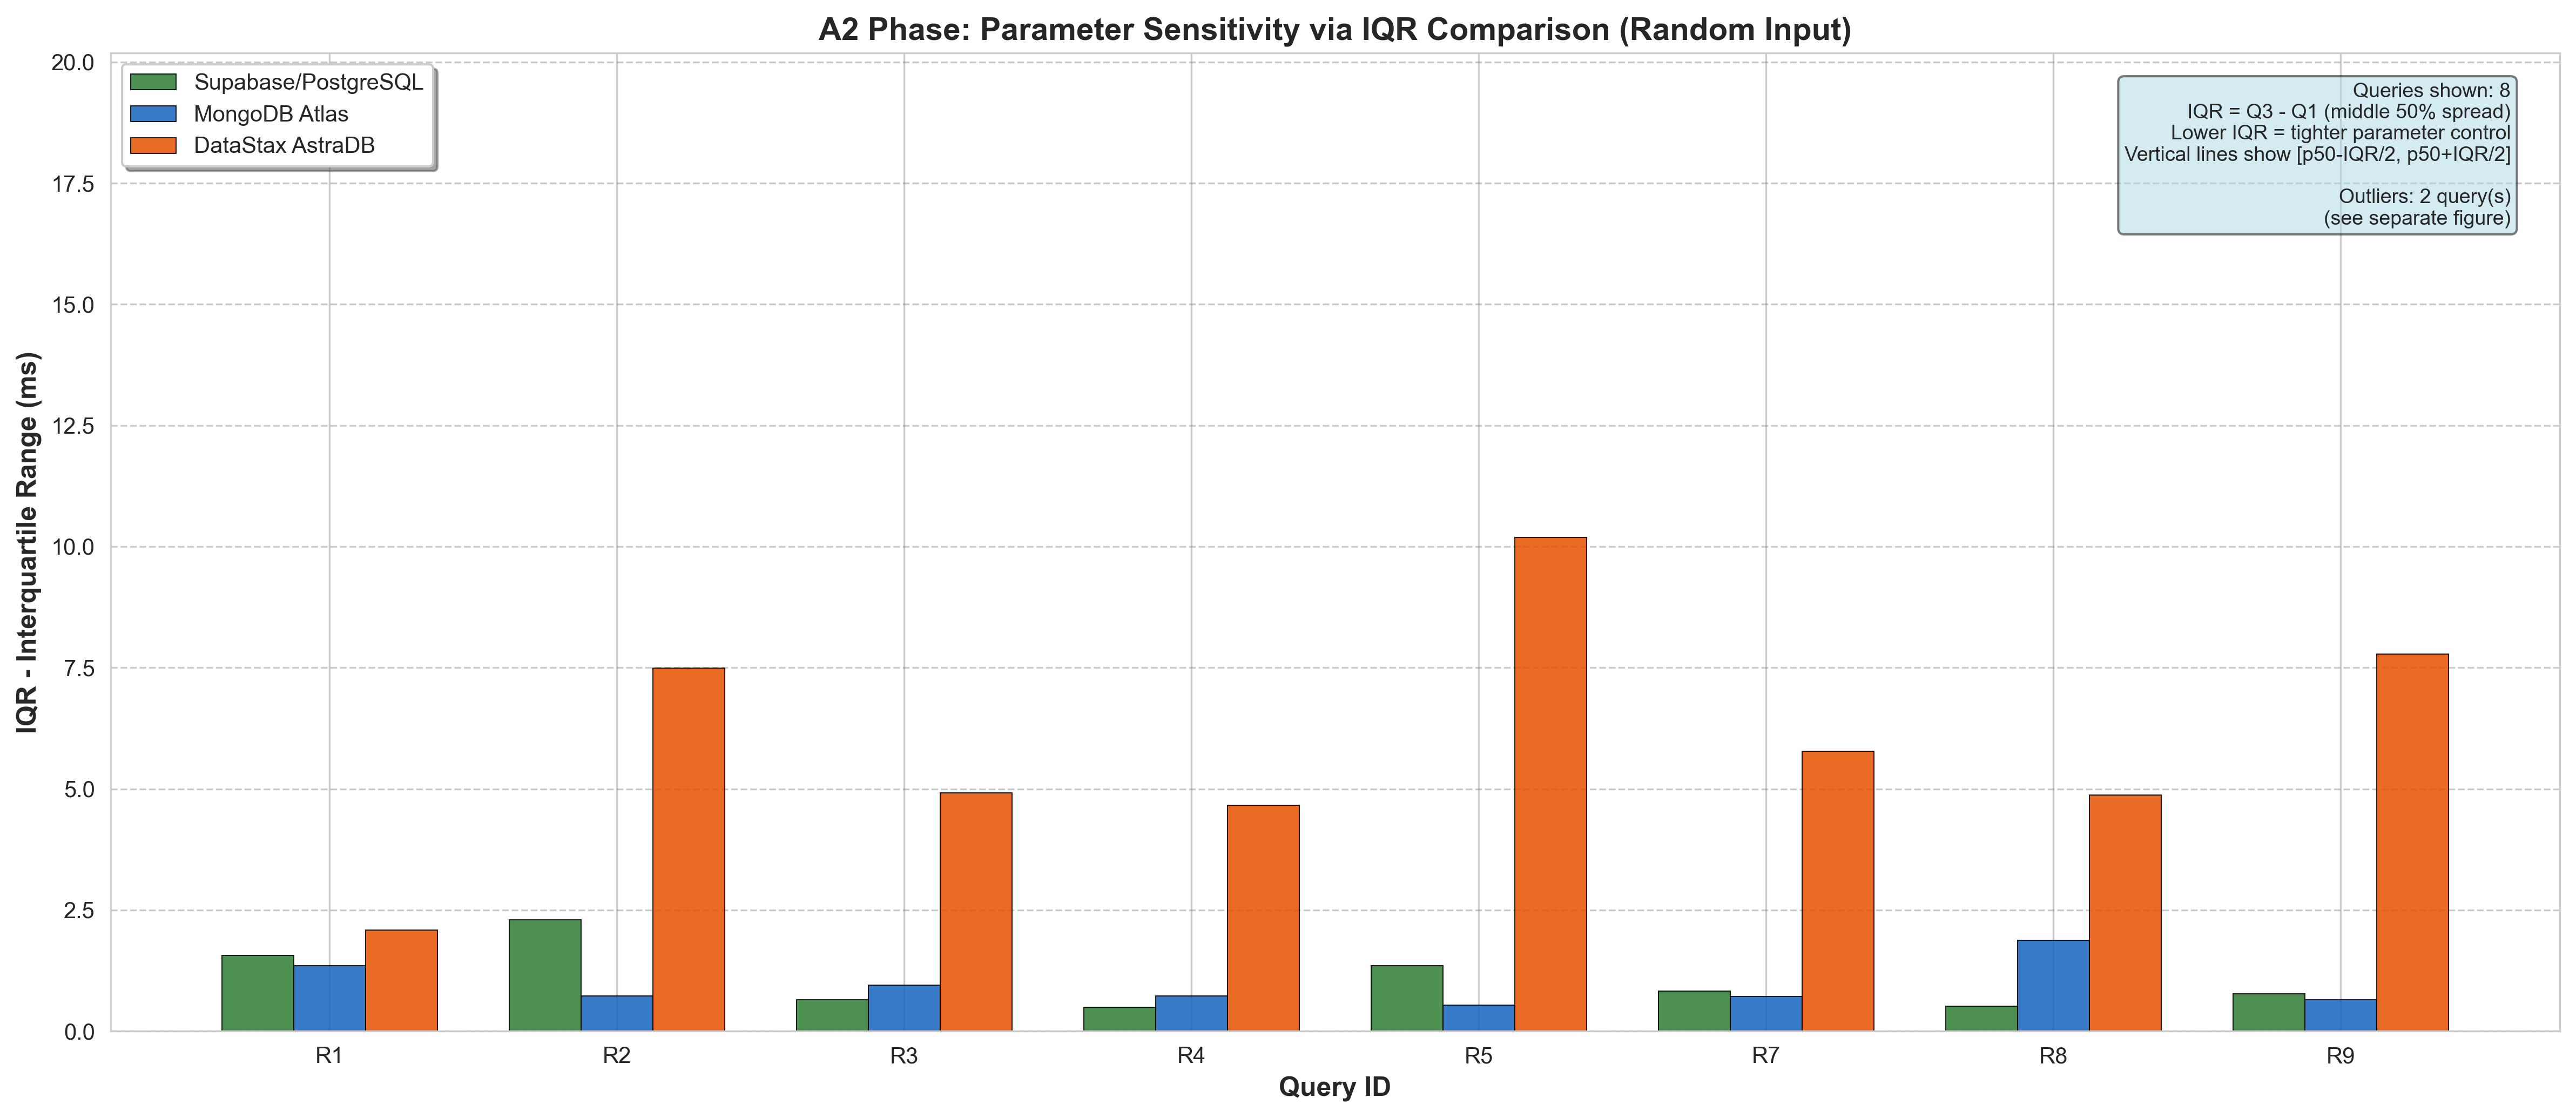

In [5]:
# Cell 5: Figure 2 - IQR Comparison Bar Chart (Normal Queries)

print("\n" + "=" * 60)
print("MAIN FIGURE GENERATION")
print("=" * 60)

# Filter to normal queries
queries_normal = [q for q in queries if q in normal_queries]
n_queries_normal = len(queries_normal)

# Extract IQR and p50 data for normal queries
supa_iqr_normal = df_supa[mask_normal]["iqr_ms"].values
mongo_iqr_normal = df_mongo[mask_normal]["iqr_ms"].values
astra_iqr_normal = df_astra[mask_normal]["iqr_ms"].values

supa_p50_normal = df_supa[mask_normal]["a2_p50_ms"].values
mongo_p50_normal = df_mongo[mask_normal]["a2_p50_ms"].values
astra_p50_normal = df_astra[mask_normal]["a2_p50_ms"].values

fig, ax = plt.subplots(figsize=(16, 7))

# Bar positioning
x = np.arange(n_queries_normal)
width = 0.25

# Positions for each database
pos_supa = x - width
pos_mongo = x
pos_astra = x + width

# Create bars with error bars showing [p50-IQR/2, p50+IQR/2] range
bars_supa = ax.bar(pos_supa, supa_iqr_normal, width, 
                   label='Supabase/PostgreSQL', 
                   color='#2E7D32', edgecolor='black', linewidth=0.5, alpha=0.85)

bars_mongo = ax.bar(pos_mongo, mongo_iqr_normal, width, 
                    label='MongoDB Atlas', 
                    color='#1565C0', edgecolor='black', linewidth=0.5, alpha=0.85)

bars_astra = ax.bar(pos_astra, astra_iqr_normal, width, 
                    label='DataStax AstraDB', 
                    color='#E65100', edgecolor='black', linewidth=0.5, alpha=0.85)

# Optional: Add error bars showing typical range [p50-IQR/2, p50+IQR/2]
# This shows where middle 50% of data falls
for i in range(n_queries_normal):
    # Supabase error bar
    lower_supa = supa_p50_normal[i] - supa_iqr_normal[i]/2
    upper_supa = supa_p50_normal[i] + supa_iqr_normal[i]/2
    ax.plot([pos_supa[i], pos_supa[i]], [lower_supa, upper_supa], 
            color='darkgreen', linewidth=1.5, alpha=0.6, zorder=5)
    
    # MongoDB error bar
    lower_mongo = mongo_p50_normal[i] - mongo_iqr_normal[i]/2
    upper_mongo = mongo_p50_normal[i] + mongo_iqr_normal[i]/2
    ax.plot([pos_mongo[i], pos_mongo[i]], [lower_mongo, upper_mongo], 
            color='darkblue', linewidth=1.5, alpha=0.6, zorder=5)
    
    # AstraDB error bar
    lower_astra = astra_p50_normal[i] - astra_iqr_normal[i]/2
    upper_astra = astra_p50_normal[i] + astra_iqr_normal[i]/2
    ax.plot([pos_astra[i], pos_astra[i]], [lower_astra, upper_astra], 
            color='darkorange', linewidth=1.5, alpha=0.6, zorder=5)

# Calculate Y-axis limit with adaptive padding
all_iqr_normal = np.concatenate([supa_iqr_normal, mongo_iqr_normal, astra_iqr_normal])
max_val = np.nanmax(all_iqr_normal)
y_range = max_val

if y_range < 20:
    padding = 10
elif y_range < 100:
    padding = 20
else:
    padding = max_val * 0.15

y_limit = max_val + padding

# Set axis properties
ax.set_xlabel('Query ID', fontweight='bold', fontsize=12)
ax.set_ylabel('IQR - Interquartile Range (ms)', fontweight='bold', fontsize=12)
ax.set_title('A2 Phase: Parameter Sensitivity via IQR Comparison (Random Input)', 
             fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(queries_normal, fontsize=10)
ax.set_ylim(0, y_limit)

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.8, color='gray')
ax.set_axisbelow(True)

# Legend
ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)

# Stats box
stats_text = (
    f"Queries shown: {n_queries_normal}\n"
    f"IQR = Q3 - Q1 (middle 50% spread)\n"
    f"Lower IQR = tighter parameter control\n"
    f"Vertical lines show [p50-IQR/2, p50+IQR/2]"
)
if len(outlier_queries) > 0:
    stats_text += f"\n\nOutliers: {len(outlier_queries)} query(s)\n(see separate figure)"

ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5, edgecolor='black'))

plt.tight_layout()
plt.savefig(fig2_filename, dpi=300, bbox_inches='tight')
print(f"✓ Figure 2 saved: {fig2_filename}")
plt.show()


OUTLIER FIGURE GENERATION
  Using log scale (range: 0.50 to 1246.54 ms)
✓ Outlier figure saved: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A2\fig2_outliers_a2_iqr_comparison.png


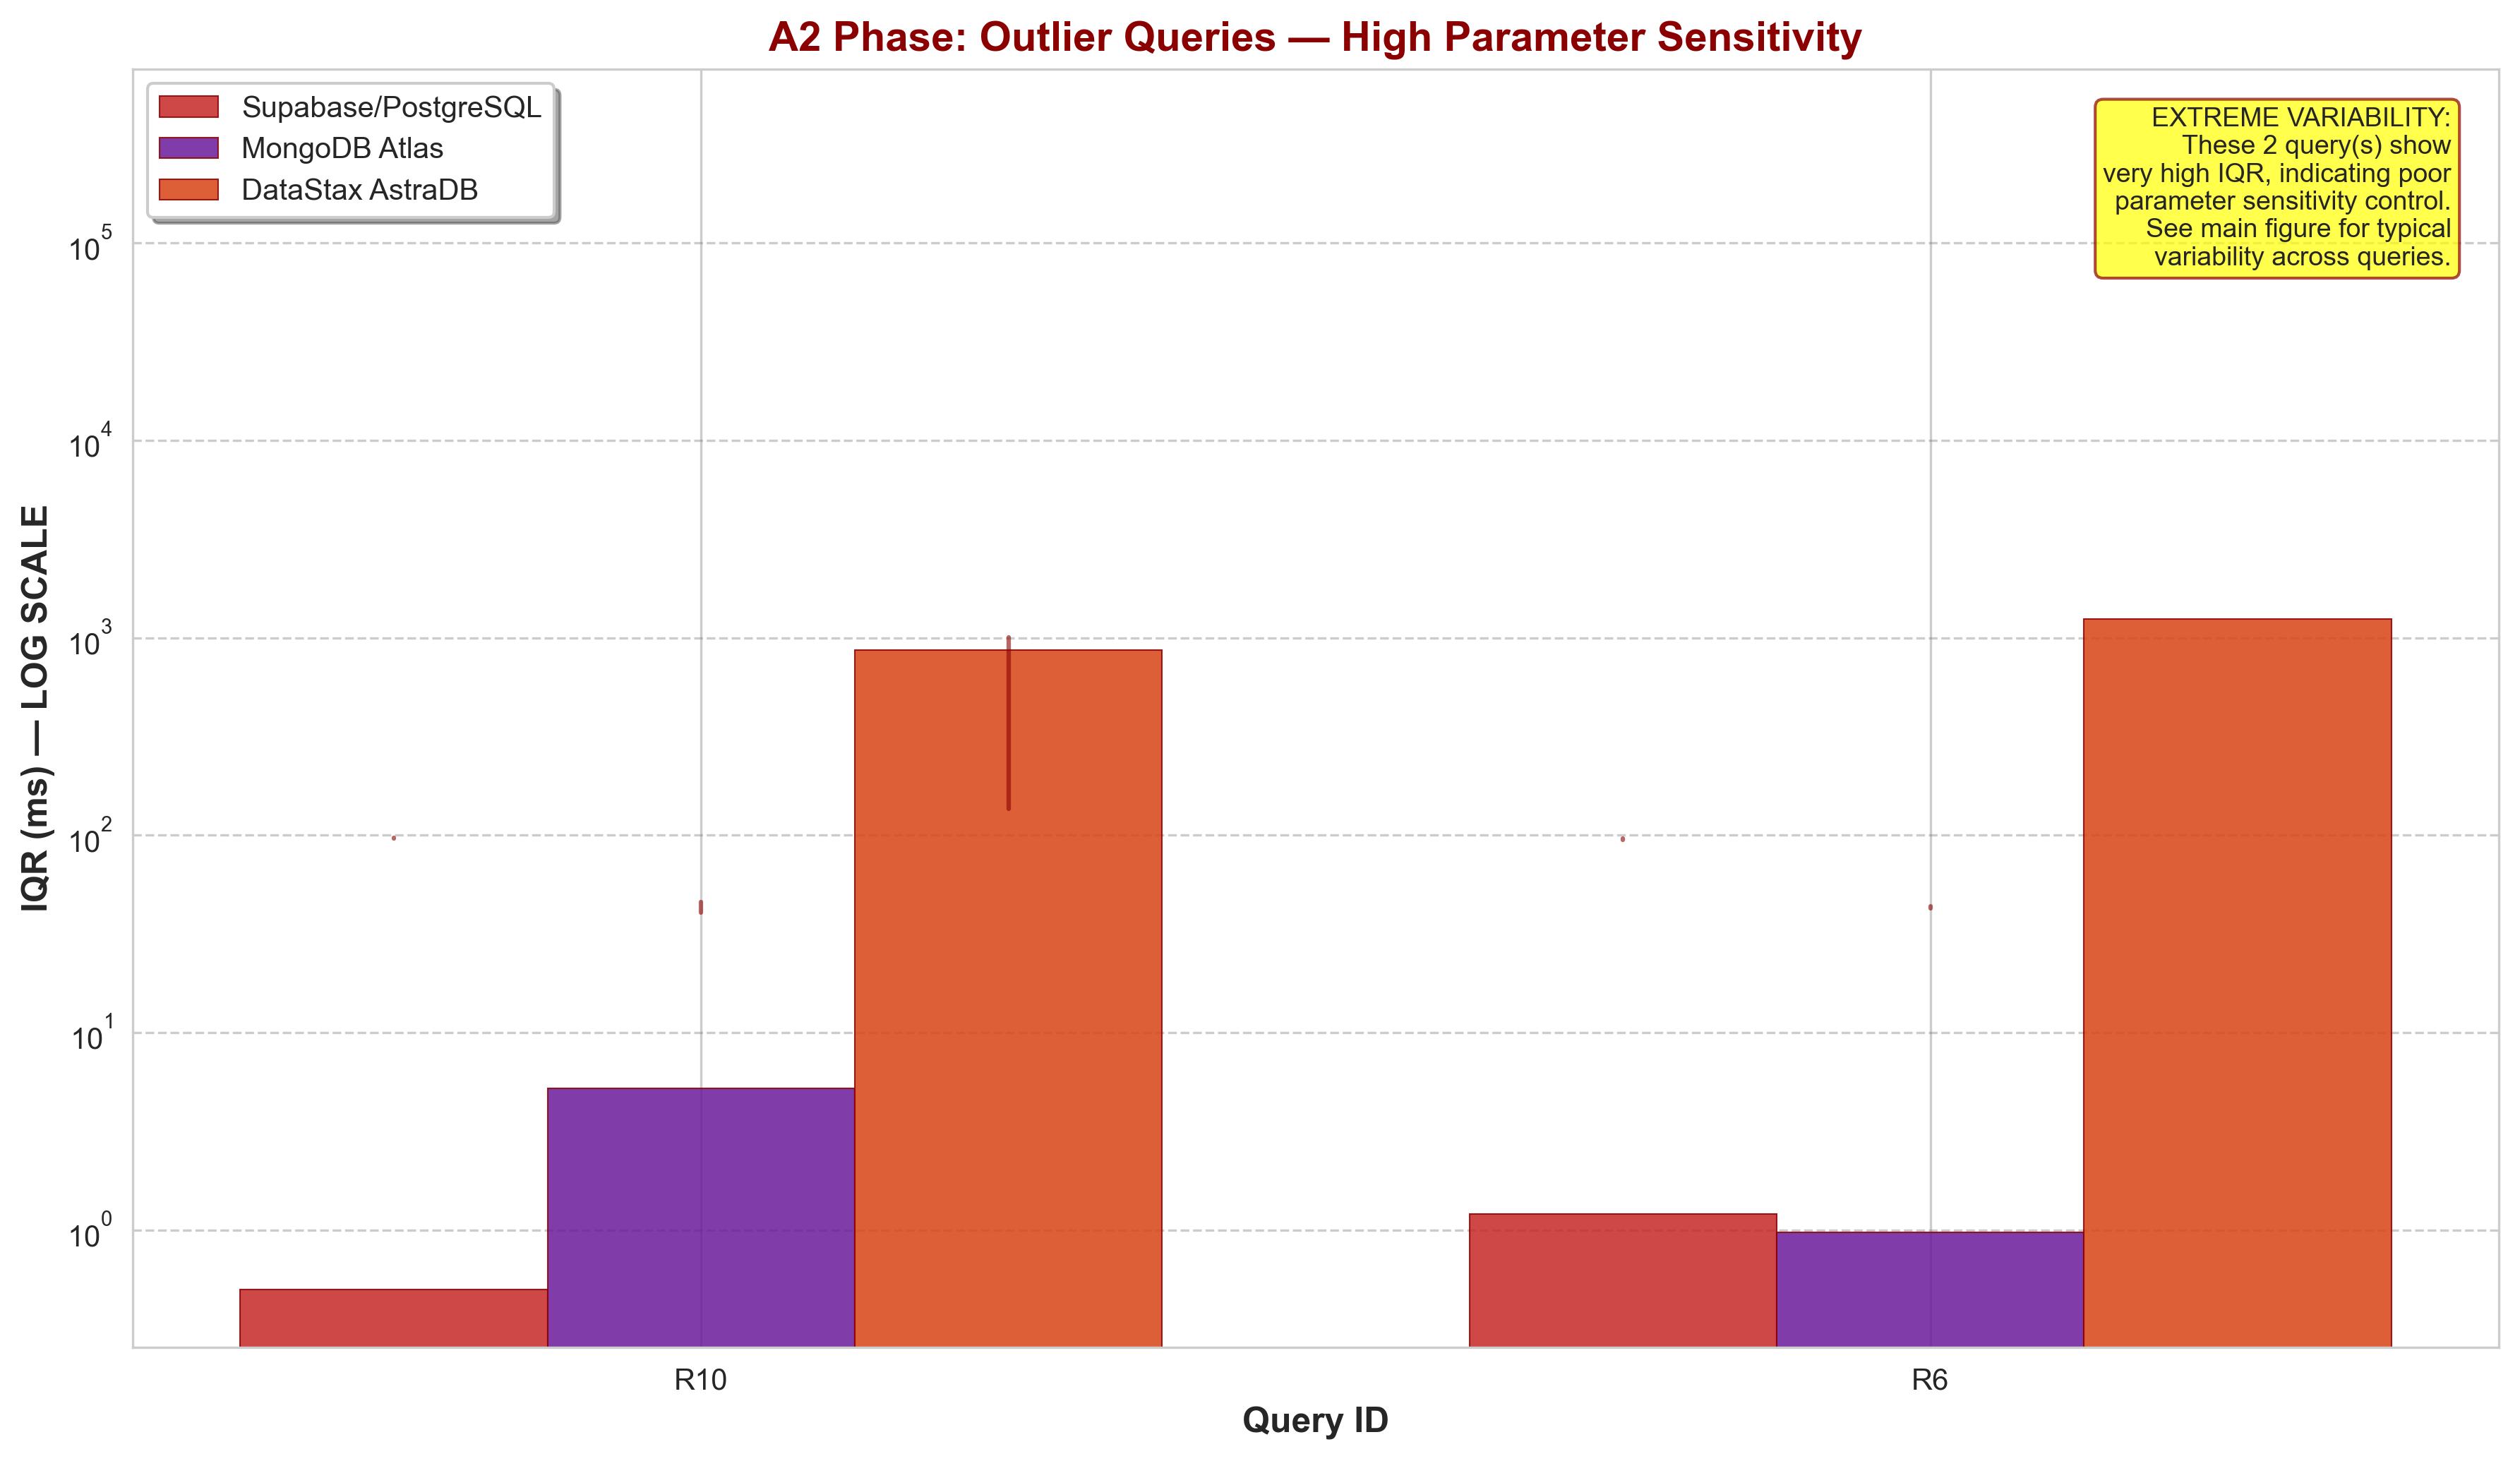

In [7]:
# Cell 6: Figure 2 Outliers - Separate visualization if outliers exist

if len(outlier_queries) > 0:
    print("\n" + "=" * 60)
    print("OUTLIER FIGURE GENERATION")
    print("=" * 60)
    
    # Filter to outlier queries
    queries_outlier = [q for q in queries if q in outlier_queries]
    n_queries_outlier = len(queries_outlier)
    
    supa_iqr_outlier = df_supa[mask_outlier]["iqr_ms"].values
    mongo_iqr_outlier = df_mongo[mask_outlier]["iqr_ms"].values
    astra_iqr_outlier = df_astra[mask_outlier]["iqr_ms"].values
    
    supa_p50_outlier = df_supa[mask_outlier]["a2_p50_ms"].values
    mongo_p50_outlier = df_mongo[mask_outlier]["a2_p50_ms"].values
    astra_p50_outlier = df_astra[mask_outlier]["a2_p50_ms"].values
    
    fig_out, ax_out = plt.subplots(figsize=(12, 7))
    
    # Bar positioning
    x_out = np.arange(n_queries_outlier)
    width = 0.25
    
    # Positions
    pos_supa = x_out - width
    pos_mongo = x_out
    pos_astra = x_out + width
    
    # Create bars (RED color scheme for outliers)
    ax_out.bar(pos_supa, supa_iqr_outlier, width, 
               label='Supabase/PostgreSQL', 
               color='#C62828', edgecolor='darkred', linewidth=0.5, alpha=0.85)
    ax_out.bar(pos_mongo, mongo_iqr_outlier, width, 
               label='MongoDB Atlas', 
               color='#6A1B9A', edgecolor='darkred', linewidth=0.5, alpha=0.85)
    ax_out.bar(pos_astra, astra_iqr_outlier, width, 
               label='DataStax AstraDB', 
               color='#D84315', edgecolor='darkred', linewidth=0.5, alpha=0.85)
    
    # Add error bars
    for i in range(n_queries_outlier):
        # Supabase
        lower = supa_p50_outlier[i] - supa_iqr_outlier[i]/2
        upper = supa_p50_outlier[i] + supa_iqr_outlier[i]/2
        ax_out.plot([pos_supa[i], pos_supa[i]], [lower, upper], 
                    color='darkred', linewidth=1.5, alpha=0.6, zorder=5)
        
        # MongoDB
        lower = mongo_p50_outlier[i] - mongo_iqr_outlier[i]/2
        upper = mongo_p50_outlier[i] + mongo_iqr_outlier[i]/2
        ax_out.plot([pos_mongo[i], pos_mongo[i]], [lower, upper], 
                    color='darkred', linewidth=1.5, alpha=0.6, zorder=5)
        
        # AstraDB
        lower = astra_p50_outlier[i] - astra_iqr_outlier[i]/2
        upper = astra_p50_outlier[i] + astra_iqr_outlier[i]/2
        ax_out.plot([pos_astra[i], pos_astra[i]], [lower, upper], 
                    color='darkred', linewidth=1.5, alpha=0.6, zorder=5)
    
    # Y-axis limits
    all_iqr_outlier = np.concatenate([supa_iqr_outlier, mongo_iqr_outlier, astra_iqr_outlier])
    out_max = np.nanmax(all_iqr_outlier)
    out_min = np.nanmin(all_iqr_outlier)
    
    # Use log scale if range is extreme (>100×)
    if out_max / max(out_min, 1) > 100:
        ax_out.set_yscale('log')
        ylabel = 'IQR (ms) — LOG SCALE'
        print(f"  Using log scale (range: {out_min:.2f} to {out_max:.2f} ms)")
    else:
        ylabel = 'IQR - Interquartile Range (ms)'
        ax_out.set_ylim(0, out_max * 1.15)
    
    # Axis properties
    ax_out.set_xlabel('Query ID', fontweight='bold', fontsize=12)
    ax_out.set_ylabel(ylabel, fontweight='bold', fontsize=12)
    ax_out.set_title('A2 Phase: Outlier Queries — High Parameter Sensitivity', 
                     fontweight='bold', fontsize=14, color='darkred')
    ax_out.set_xticks(x_out)
    ax_out.set_xticklabels(queries_outlier, fontsize=10)
    ax_out.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.8, color='gray')
    ax_out.set_axisbelow(True)
    ax_out.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
    
    # Warning box
    warn_text = (
        f"EXTREME VARIABILITY:\n"
        f"These {n_queries_outlier} query(s) show\n"
        f"very high IQR, indicating poor\n"
        f"parameter sensitivity control.\n"
        f"See main figure for typical\n"
        f"variability across queries."
    )
    ax_out.text(0.98, 0.97, warn_text, transform=ax_out.transAxes,
                fontsize=9, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7, edgecolor='darkred'))
    
    plt.tight_layout()
    plt.savefig(fig2_outlier_filename, dpi=300, bbox_inches='tight')
    print(f"✓ Outlier figure saved: {fig2_outlier_filename}")
    plt.show()
else:
    print("\n✓ No outliers detected — skipping outlier figure")

In [8]:
# Cell 7: Summary

print("\n" + "=" * 60)
print("A2 IQR FIGURE GENERATION COMPLETE")
print("=" * 60)

print(f"\n📊 Databases processed: Supabase, MongoDB, AstraDB")
print(f"📁 Figures saved to: {output_dir}\n")

if len(outlier_queries) > 0:
    print(f"  Figure 2 (Main): {os.path.basename(fig2_filename)}")
    print(f"    └─ {len(normal_queries)} normal queries")
    print(f"  Figure 2 (Outliers): {os.path.basename(fig2_outlier_filename)}")
    print(f"    └─ {len(outlier_queries)} outlier query(s): {outlier_queries}")
else:
    print(f"  Figure 2: {os.path.basename(fig2_filename)}")
    print(f"    └─ All {len(queries)} queries (no outliers)")

print("\n✓ Figure(s) generated successfully!")
print("\n📌 Key insights to look for:")
print("  - Lower IQR bars = better parameter sensitivity control")
print("  - Vertical lines show typical data spread (middle 50%)")
print("  - Compare IQR across databases per query to find winner")
if len(outlier_queries) > 0:
    print("  - Outlier figure: Why such high variability for these queries?")


A2 IQR FIGURE GENERATION COMPLETE

📊 Databases processed: Supabase, MongoDB, AstraDB
📁 Figures saved to: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\A2

  Figure 2 (Main): fig2_a2_iqr_comparison_combined.png
    └─ 8 normal queries
  Figure 2 (Outliers): fig2_outliers_a2_iqr_comparison.png
    └─ 2 outlier query(s): ['R10', 'R6']

✓ Figure(s) generated successfully!

📌 Key insights to look for:
  - Lower IQR bars = better parameter sensitivity control
  - Vertical lines show typical data spread (middle 50%)
  - Compare IQR across databases per query to find winner
  - Outlier figure: Why such high variability for these queries?
